In [1]:
!pip install torchinfo -q

In [2]:
import os
import json
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models import resnet50, ResNet50_Weights
from torchinfo import summary


from sklearn.model_selection import train_test_split

# Config

In [3]:

path = '/kaggle/input/datasets/b22dckh065vgiakhi/icpr-ds'
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset config
vocab = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
num_classes = len(vocab)   # 36
label_len = 7
img_H, img_W = 32, 128

# Model config
embed_dim = 512
ff_dim = 512 * 4
num_layers = 3
num_heads = 8
drop_out = 0.1

# Training config
lr = 5e-4
batch_size = 64
epochs = 30
log_interval = 1
early_stop_count = 5
warmup_epochs = 3
train_loss = []
val_loss = []
train_acc = []
val_acc = []
best_model_path = '/kaggle/working/ResTranOCR.pth'

# Set Seed

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

In [5]:
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-A', 'Brazilian'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-A', 'Mercosur'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-B', 'Brazilian'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-B', 'Mercosur'))) * 10)

50000
50000
20000
80000


# Dataset

In [6]:
class ICPRDataSet(Dataset):
    def __init__(self, path, split='train', val_size=0.2, random_state=42, transform=None):
        self.transform = transform
        self.split = split
        self.degradation = self.get_degradation_transforms()

        if split in ['train', 'val', 'test']:
            data_path = os.path.join(path, 'train')
            all_tracks = self.get_path(data_path, split='train')
            train_tracks, temp_tracks = self.split_tracks(
                all_tracks, test_size=val_size, random_state=random_state
            )
            val_tracks, test_tracks = self.split_tracks(
                temp_tracks, test_size=0.5, random_state=random_state
            )
            if split == 'train':
                self.tracks = train_tracks
            elif split == 'val':
                self.tracks = val_tracks
            elif split == 'test':
                self.tracks = test_tracks
        elif split == 'blind_test':
            data_path = os.path.join(path, 'test')
            self.tracks = self.get_path(data_path, split='test')

        # Flatten thành list các entry, mỗi track tạo 2 entry khi train
        self.entries = self.build_entries(self.tracks)

        print(f'Split: {split}')
        print(f'Number of tracks: {len(self.tracks)}')
        print(f'Number of samples (entries): {len(self.entries)}')

    def get_path(self, path, split):
        tracks = {}
        track_paths = []

        if split == 'test':
            track_names = os.listdir(path)
            for track_name in track_names:
                track_paths.append(os.path.join(path, track_name))
        else:
            scennarios = ['Scenario-A', 'Scenario-B']
            countries = ['Brazilian', 'Mercosur']
            for scennario in scennarios:
                for countrie in countries:
                    data_path = os.path.join(path, scennario, countrie)
                    if not os.path.isdir(data_path):
                        continue
                    for track_name in os.listdir(data_path):
                        track_paths.append(os.path.join(data_path, track_name))

        for track_path in track_paths:
            track_id = os.path.basename(track_path)
            track_lr = []
            track_hr = []
            track_label = None

            for item in os.listdir(track_path):
                item_path = os.path.join(track_path, item)
                if item.lower().startswith('lr'):
                    track_lr.append(item_path)
                elif item.lower().startswith('hr'):
                    track_hr.append(item_path)
                elif item.lower().endswith('.json') and split != 'test':
                    with open(item_path, 'r', encoding='utf-8') as f:
                        annotations = json.load(f)
                    track_label = annotations.get('plate_text').strip()

            tracks[track_id] = {
                'track_path': track_path,
                'lr_paths': sorted(track_lr),
                'hr_paths': sorted(track_hr),
                'label': track_label
            }

        return tracks

    def split_tracks(self, tracks, test_size=0.1, random_state=42):
        track_ids = sorted(tracks.keys())
        train_ids, val_ids = train_test_split(
            track_ids,
            test_size=test_size,
            random_state=random_state,
            shuffle=True
        )
        train_tracks = {tid: tracks[tid] for tid in train_ids}
        val_tracks = {tid: tracks[tid] for tid in val_ids}
        return train_tracks, val_tracks

    def build_entries(self, tracks):
        entries = []
        for track_id, track in tracks.items():
            # Entry 1: LR gốc
            entries.append({
                'entry_id': track_id + '_lr',
                'paths': track['lr_paths'],
                'use_hr': False,
                'label': track['label']
            })
            # Entry 2: HR-degrade (chỉ train)
            if self.split == 'train' and len(track['hr_paths']) > 0:
                entries.append({
                    'entry_id': track_id + '_hr',
                    'paths': track['hr_paths'],
                    'use_hr': True,
                    'label': track['label']
                })
        return entries

    def get_degradation_transforms(self):
        return A.Compose([
            A.OneOf([
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.MotionBlur(blur_limit=(3, 5), p=1.0)
            ], p=0.7),
            A.OneOf([
                A.GaussNoise(noise_scale_factor=0.1, p=1.0),
                A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0)
            ], p=0.7),
            A.ImageCompression(quality_range=(20, 50), p=0.5),
            A.Downscale(scale_range=(0.3, 0.5), p=0.5) 
        ])

    
    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]

        images = []
        for img_path in entry['paths']:          # luôn đúng 5 frames
            img = np.array(Image.open(img_path).convert('RGB'))

            if entry['use_hr']:
                img = self.degradation(image=img)['image']  # HR → pseudo-LR

            if self.transform is not None:
                img = self.transform(image=img)['image']

            images.append(img)

        return {
            'track_id': entry['entry_id'],
            'images': images,                    # luôn 5 phần tử
            'label': entry['label']
        }

In [7]:
train_transforms = A.Compose([
    A.Resize(height=img_H, width=img_W),
    A.Affine(
        scale=(0.95, 1.05),
        translate_percent=(0.05, 0.05),
        rotate=(-5, 5),
        fill=128,
        p=0.5
    ),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
    A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=20,
            p=0.3
    ),
    A.ChannelShuffle(p=0.3),
    A.CoarseDropout(
            num_holes_range=(2, 5),
            hole_height_range=(4, 8),
            hole_width_range=(4, 8),
            p=0.3
    ),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_test_transforms = A.Compose([
    A.Resize(height=img_H, width=img_W),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

In [8]:
def encode_label(label: str) -> torch.Tensor:
    return torch.tensor(
        [vocab.index(c) for c in label.upper()],
        dtype=torch.long
    )  # shape (7,)

In [9]:
# def encode_label(label: str) -> torch.Tensor:
#     for c in label.upper():
#         if c not in vocab:
#             print(f'[BAD CHAR] label="{label}", char="{c}", ord={ord(c)}')
#     return torch.tensor(
#         [vocab.index(c) for c in label.upper()],
#         dtype=torch.long
#     )

In [10]:
def collate_fn_train(batch):
    images = torch.stack([torch.stack(item['images']) for item in batch])
    # (B, F, C, H, W)
    targets = torch.stack([encode_label(item['label']) for item in batch])
    # (B, 7)
    return images, targets


def collate_fn_test(batch):
    images = torch.stack([torch.stack(item['images']) for item in batch])
    # (B, F, C, H, W)
    track_ids = [item['track_id'] for item in batch]
    return images, track_ids

In [11]:
train_dataset = ICPRDataSet(path, split='train', transform=train_transforms)
val_dataset = ICPRDataSet(path, split='val', transform=val_test_transforms)
test_dataset = ICPRDataSet(path, split='test', transfrom=val_test_transforms)
blind_test_dataset = ICPRDataSet(path, split='blind_test', transform=val_test_transforms)

Split: train
Number of tracks: 18000
Number of samples (entries): 36000
Split: val
Number of tracks: 2000
Number of samples (entries): 2000
Split: test
Number of tracks: 1000
Number of samples (entries): 1000


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_train,
    num_workers=4,       
    pin_memory=True      
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_train,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_train,
    num_workers=4,
    pin_memory=True
)

blind_test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_test)

In [13]:
def unnormalize(tensor):
    """tensor: (C, H, W)"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


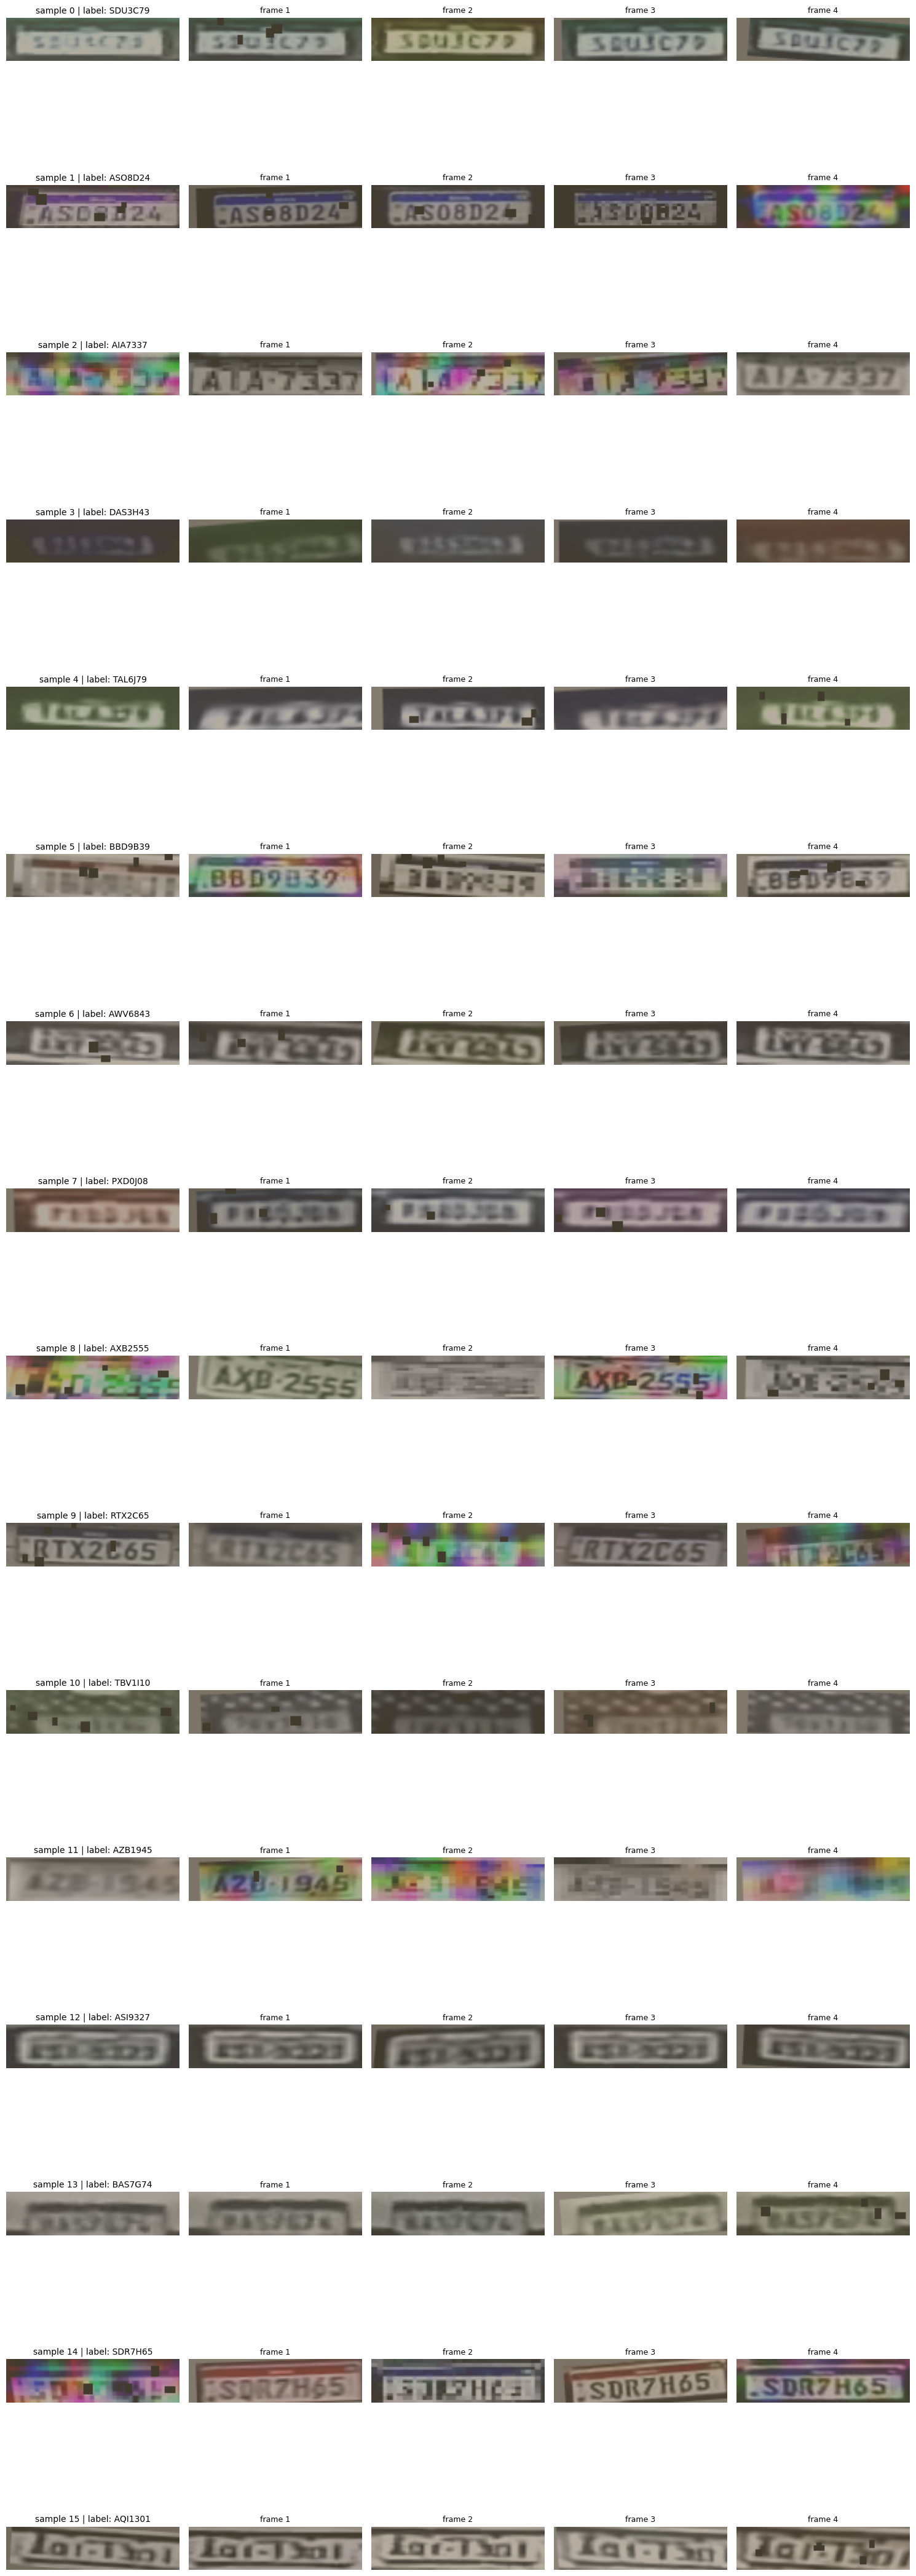

Batch shape: torch.Size([64, 5, 3, 32, 128]), Targets shape: torch.Size([64, 7])


In [14]:
# Visualize one batch from train_loader
images, targets = next(iter(train_loader))  # images: (B, F, C, H, W), targets: (B, 7)

B, Fm, C, H, W = images.shape
show_samples = min(16, B)
show_frames = min(5, Fm)

fig, axes = plt.subplots(show_samples, show_frames, figsize=(3 * show_frames, 2.8 * show_samples))

# Normalize axes shape for cases when rows/cols == 1
if show_samples == 1 and show_frames == 1:
    axes = np.array([[axes]])
elif show_samples == 1:
    axes = axes[np.newaxis, :]
elif show_frames == 1:
    axes = axes[:, np.newaxis]

for i in range(show_samples):
    label_str = ''.join(vocab[idx] for idx in targets[i].tolist())
    for j in range(show_frames):
        img = unnormalize(images[i, j].cpu())

        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_title(f'sample {i} | label: {label_str}', fontsize=10)
        else:
            ax.set_title(f'frame {j}', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Batch shape: {images.shape}, Targets shape: {targets.shape}')

# Baseline 1: Multi Frame ORC - ResNet50 + Transformer

In [15]:
class STNBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.localization = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=5, stride=2, padding=2),
            nn.MaxPool2d(2, 2),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d((4, 8))
        )
        self.fc_loc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 8, 128),
            nn.ReLU(True),
            nn.Linear(128, 6)
        )
        with torch.no_grad():
            self.fc_loc[-1].weight.zero_()
            self.fc_loc[-1].bias.copy_(
                torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float)
            )
    
    def forward(self, x):
        x = self.localization(x)
        x = self.fc_loc(x)
        x = x.view(-1, 2, 3)
        return x

In [17]:
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, pretrained=True, out_dim=512, freeze_backbone=False):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = resnet50(weights=weights)

        self.conv1   = backbone.conv1
        self.bn1     = backbone.bn1
        self.relu    = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4

        # Modify stride (2,2) -> (2,1) in layer3 và layer4, keep w, shrink h only

        self.layer3[0].conv2.stride = (2, 1)
        self.layer3[0].downsample[0].stride = (2, 1)

        self.layer4[0].conv2.stride = (2, 1)
        self.layer4[0].downsample[0].stride = (2, 1)

        # Project 2048 -> out_dim
        self.proj = nn.Conv2d(2048, out_dim, kernel_size=1)

        if freeze_backbone:
            for name, p in self.named_parameters():
                if 'proj' not in name:
                    p.requires_grad = False

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.proj(x)                              # (B, out_dim, H', W')

        # Collapse height → 1, giữ width làm sequence
        x = F.adaptive_avg_pool2d(x, (1, None))       # (B, out_dim, 1, W')
        return x

In [18]:
class AttentionFusion(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.score_net = nn.Sequential(
            nn.Conv2d(channels, channels // 8, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 8, 1, kernel_size=1)
        )

    def forward(self, x):
        total_frames, C, H, W = x.size()
        num_frames = 5
        batch_size = total_frames // num_frames

        # Reshape to [Batch_size, Frames, C, H, W]
        x_view = x.view(batch_size, num_frames, C, H, W)

        # Calculate attention scores [Batch_size, Frames, 1, H, W]
        scores = self.score_net(x).view(batch_size, num_frames, 1, H, W)
        weights = F.softmax(scores, dim=1)

        # Weight sim fusion
        fused_features = torch.sum(x_view * weights, dim=1)
        return fused_features

In [19]:
class pos_encoding(nn.Module):
    def __init__(self, embed_dim, max_length=500):
        super().__init__()
        self.pos_encoding = nn.Parameter(
            (embed_dim ** -0.5) * torch.randn(1, max_length, embed_dim)
        )

    def forward(self, x):
        B, T, C = x.shape
        return x + self.pos_encoding[:, :T, :]

In [20]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, ff_dim, num_heads, drop_out):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=drop_out, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.layernorm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.drop1 = nn.Dropout(drop_out)
        self.drop2 = nn.Dropout(drop_out)

    def forward(self, q, k, v):
        q_norm = self.layernorm1(q)
        k_norm = self.layernorm1(k)
        v_norm = self.layernorm1(v)

        attn_out, _ = self.attn(q_norm, k_norm, v_norm)
        attn_out = self.drop1(attn_out)
        out1 = attn_out + q

        out1_norm = self.layernorm2(out1)
        ff_out = self.ff(out1_norm)
        ff_out = self.drop2(ff_out)
        out2 = ff_out + out1

        return out2

In [21]:
class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, ff_dim, num_layers, num_heads, drop_out):
        super().__init__()

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim, ff_dim, num_heads, drop_out
            ) for _ in range(num_layers)
        ])

    def forward(self, x):
        output = x
        for block in self.blocks:
            output = block(output, output, output)
        return output

In [22]:
class ResTranOCR(nn.Module):
    def __init__(self, label_len, num_classes, embed_dim, ff_dim, num_layers, num_heads,
                 extractor_pretrained=True, freeze_extractor=True, drop_out=0.1):
        super().__init__()
        self.label_len = label_len
        self.stn           = STNBlock(3)
        self.extractor     = ResNetFeatureExtractor(pretrained=extractor_pretrained,
                                      out_dim=embed_dim,
                                      freeze_backbone=freeze_extractor)
        self.attn_fusion   = AttentionFusion(embed_dim)
        self.pos_encoder   = pos_encoding(embed_dim, max_length=5000)
        self.transformer_layer = TransformerEncoder(
            embed_dim, ff_dim, num_layers, num_heads, drop_out
        )
        # Thay vì (embed_dim → 37), giờ dùng adaptive pool → Linear
        self.head = nn.Linear(embed_dim, num_classes)  # 36

    def forward(self, x):
        B, Frames, C, H, W = x.size()

        x_flat    = x.view(B * Frames, C, H, W)
        theta     = self.stn(x_flat)
        grid      = F.affine_grid(theta, x_flat.size(), align_corners=False)
        x_aligned = F.grid_sample(x_flat, grid, align_corners=False)

        features  = self.extractor(x_aligned)       # (B*F, embed_dim, H', W')

        fused     = self.attn_fusion(features)       # (B, embed_dim, H', W')

        seq_input = fused.squeeze(2).permute(0, 2, 1)  # (B, W', out_dim)
        seq_input = self.pos_encoder(seq_input)
        seq_out   = self.transformer_layer(seq_input)   # (B, T, embed_dim)

        # Pool T timestep → đúng 7 vị trí
        # AdaptiveAvgPool hoạt động trên dim T
        seq_out = seq_out.permute(0, 2, 1)              # (B, embed_dim, T)
        seq_out = F.adaptive_avg_pool1d(seq_out, self.label_len)  # (B, embed_dim, 7)
        seq_out = seq_out.permute(0, 2, 1)              # (B, 7, embed_dim)

        out = self.head(seq_out)                        # (B, 7, 36)
        return out                                      

In [23]:
model = ResTranOCR(
    label_len=label_len,
    num_classes=num_classes,
    embed_dim=embed_dim,
    ff_dim=ff_dim,
    num_layers=num_layers,
    num_heads=num_heads,
    extractor_pretrained=True,
    freeze_extractor=True,
    drop_out=drop_out
    ).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s] 


In [24]:
summary(model, input_size=(1, 5, 3, img_H, img_W), device='cpu')

Layer (type:depth-idx)                             Output Shape              Param #
ResTranOCR                                         [1, 7, 36]                --
├─STNBlock: 1-1                                    [5, 2, 3]                 --
│    └─Sequential: 2-1                             [5, 64, 4, 8]             --
│    │    └─Conv2d: 3-1                            [5, 32, 16, 64]           2,432
│    │    └─MaxPool2d: 3-2                         [5, 32, 8, 32]            --
│    │    └─ReLU: 3-3                              [5, 32, 8, 32]            --
│    │    └─Conv2d: 3-4                            [5, 64, 8, 32]            18,496
│    │    └─ReLU: 3-5                              [5, 64, 8, 32]            --
│    │    └─AdaptiveAvgPool2d: 3-6                 [5, 64, 4, 8]             --
│    └─Sequential: 2-2                             [5, 6]                    --
│    │    └─Flatten: 3-7                           [5, 2048]                 --
│    │    └─Linear: 3-8     

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6
)

In [26]:
def decode_pred(logits):
    """logits: (B, 7, 36) → list of str"""
    indices = logits.argmax(dim=2)  # (B, 7)
    return ["".join(vocab[i] for i in seq.tolist()) for seq in indices]

In [27]:
def compute_accuracy(logits, targets):
    """Sequence accuracy — đúng cả 7 ký tự mới tính đúng"""
    preds = logits.argmax(dim=2)    # (B, 7)
    correct = (preds == targets).all(dim=1).sum().item()
    return correct / targets.size(0)

In [28]:
# For multi-gpu
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

Using 2 GPUs


# Training

In [29]:
def visualize_val_samples(model, val_loader, device, n_samples=2):
    """Lấy batch đầu val, show n_samples — mỗi sample 1 hàng gồm frame 0."""
    model.eval()
    images, targets = next(iter(val_loader))
    images_dev = images[:n_samples].to(device)

    with torch.no_grad():
        logits = model(images_dev)                     # (n, 7, 36)

    preds = decode_pred(logits.cpu())                  # list of str
    gts   = [''.join(vocab[i] for i in t.tolist())
              for t in targets[:n_samples]]            # list of str

    fig, axes = plt.subplots(
        n_samples, 1,
        figsize=(6, 2.5 * n_samples)
    )
    if n_samples == 1:
        axes = [axes]

    for i in range(n_samples):
        ax = axes[i]
        img = unnormalize(images[i, 0].cpu())          # frame 0, (H,W,C)
        ax.imshow(img)
        ax.axis('off')

        correct = preds[i] == gts[i]
        color   = 'green' if correct else 'red'
        ax.set_title(
            f'GT: {gts[i]}   |   Pred: {preds[i]}',
            fontsize=11, color=color, fontweight='bold'
        )

    plt.suptitle('Val sample preview', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [30]:
def train(model, optimizer, scheduler, criterion,
          train_loader, val_loader,
          epochs, early_stop_count, best_model_path,
          log_interval, warmup_epochs=0, device='cpu'):

    # best_val_loss = float('inf')
    best_val_acc = 0.0 # switch to acc for orc all 7 char 
    break_count   = 0
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []

    base_model = model.module if isinstance(model, nn.DataParallel) else model

    if warmup_epochs > 0:
        for p in base_model.extractor.parameters():
            p.requires_grad = False
        print(f'Warmup: freeze extractor for first {warmup_epochs} epochs')

    for epoch in tqdm(range(epochs), desc='Epoch', position=0):

        if warmup_epochs > 0 and epoch == warmup_epochs:
            for p in base_model.extractor.parameters():
                p.requires_grad = True
            print(f'Unfreeze extractor at epoch {epoch}')

        # Train 
        model.train()
        if warmup_epochs > 0 and epoch < warmup_epochs:
            base_model.extractor.eval()

        epoch_loss = epoch_acc = 0

        for images, targets in tqdm(train_loader, desc='Train', position=1, leave=False):
            images  = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(images)

            loss = criterion(logits.permute(0, 2, 1), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc  += compute_accuracy(logits.detach().cpu(), targets.cpu())

        train_loss_hist.append(epoch_loss / len(train_loader))
        train_acc_hist.append(epoch_acc  / len(train_loader))

        # Validation
        model.eval()
        epoch_loss = epoch_acc = 0

        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc='Val', position=1, leave=False):
                images  = images.to(device)
                targets = targets.to(device)

                logits = model(images)
                loss   = criterion(logits.permute(0, 2, 1), targets)

                epoch_loss += loss.item()
                epoch_acc  += compute_accuracy(logits.cpu(), targets.cpu())

        val_loss_hist.append(epoch_loss / len(val_loader))
        val_acc_hist.append(epoch_acc  / len(val_loader))

        scheduler.step()

        # Log + Visual 
        if epoch % log_interval == 0:
            print(
                f'| Epoch {epoch:3d} '
                f'| Train Loss {train_loss_hist[-1]:.4f}  Acc {train_acc_hist[-1]:.4f} '
                f'| Val Loss {val_loss_hist[-1]:.4f}  Acc {val_acc_hist[-1]:.4f} |'
            )
            visualize_val_samples(model, val_loader, device, n_samples=2)

        # Checkpoint + Early stop
        if val_acc_hist[-1] > best_val_acc:
            break_count   = 0
            best_val_acc = val_acc_hist[-1]
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_loss':        best_val_loss,
                'best_val_acc':         val_acc_hist[-1],
                'break_count':          break_count,
                'train_loss_hist':      train_loss_hist,
                'val_loss_hist':        val_loss_hist,
                'train_acc_hist':       train_acc_hist,
                'val_acc_hist':         val_acc_hist,
            }, best_model_path)
        else:
            break_count += 1

        if break_count >= early_stop_count:
            print(f'Early stop tại epoch {epoch} | best val loss: {best_val_loss:.4f}')
            break

        train_loss.append(train_loss_hist[-1])
        val_loss.append(val_loss_hist[-1])
        train_acc.append(train_acc_hist[-1])
        val_acc.append(val_acc_hist[-1])

    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print('Training hoàn tất, đã load best model')

    return model, {
        'train_loss': train_loss_hist,
        'val_loss':   val_loss_hist,
        'train_acc':  train_acc_hist,
        'val_acc':    val_acc_hist,
    }

Warmup: freeze extractor for first 3 epochs


Epoch:   0%|          | 0/30 [00:00<?, ?it/s]

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   0 | Train Loss 2.3302  Acc 0.0002 | Val Loss 2.0796  Acc 0.0000 |


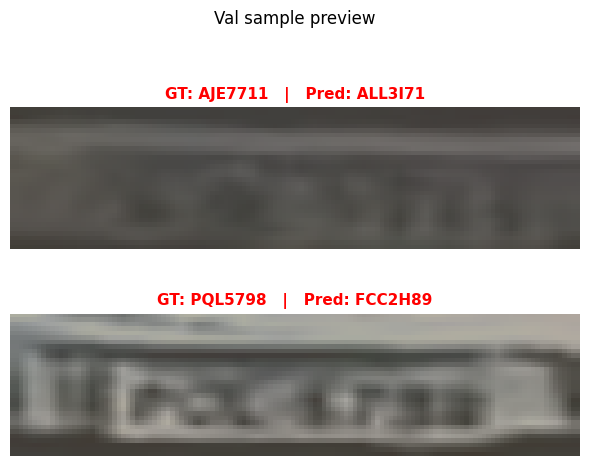

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   1 | Train Loss 1.6715  Acc 0.0112 | Val Loss 1.7091  Acc 0.0088 |


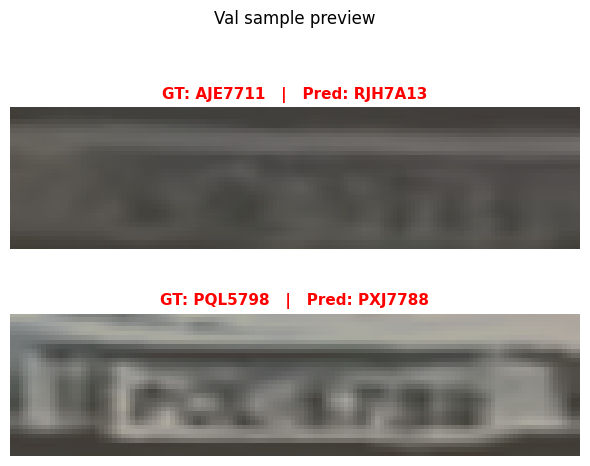

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   2 | Train Loss 1.3405  Acc 0.0443 | Val Loss 1.4921  Acc 0.0293 |


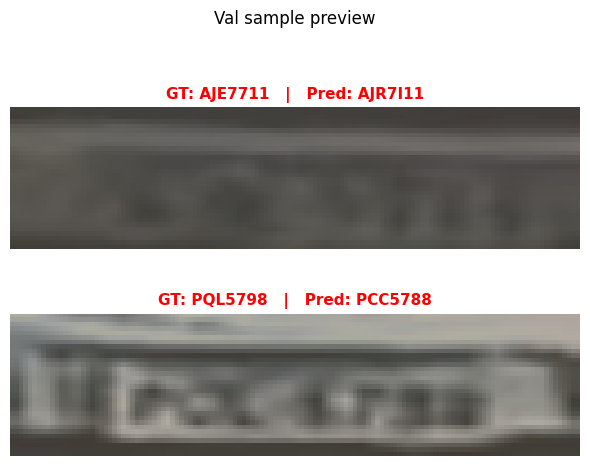

Unfreeze extractor at epoch 3


Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   3 | Train Loss 0.6973  Acc 0.3971 | Val Loss 0.6904  Acc 0.3569 |


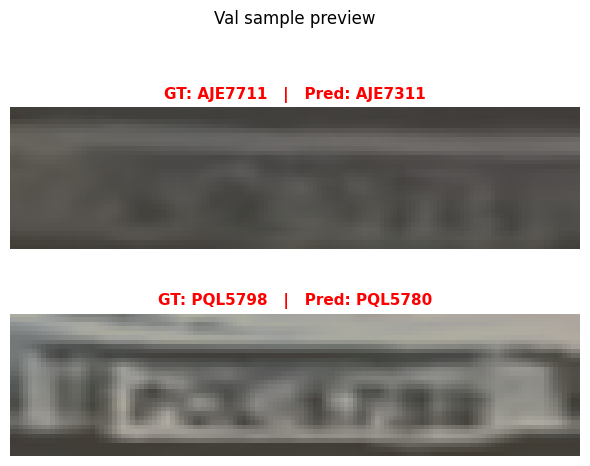

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   4 | Train Loss 0.2968  Acc 0.6655 | Val Loss 0.4314  Acc 0.5630 |


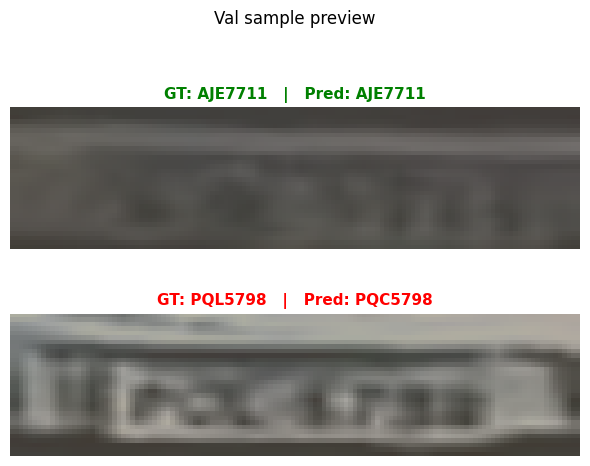

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   5 | Train Loss 0.2323  Acc 0.7277 | Val Loss 0.4158  Acc 0.6108 |


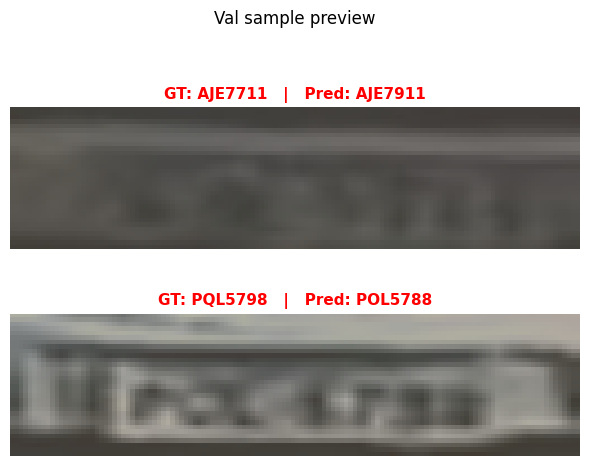

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   6 | Train Loss 0.2032  Acc 0.7534 | Val Loss 0.3845  Acc 0.6279 |


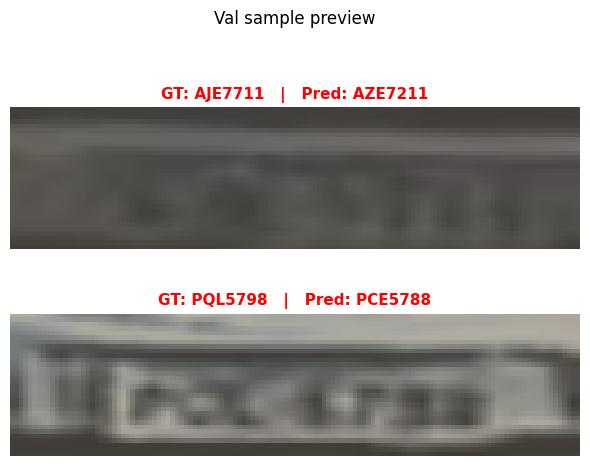

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   7 | Train Loss 0.1812  Acc 0.7780 | Val Loss 0.3814  Acc 0.6133 |


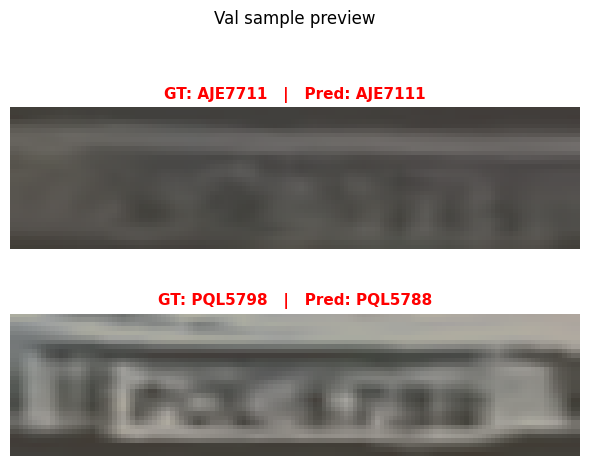

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   8 | Train Loss 0.1668  Acc 0.7940 | Val Loss 0.3417  Acc 0.6450 |


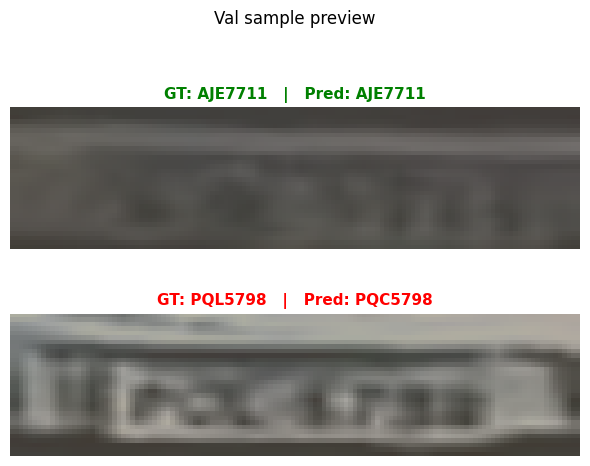

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   9 | Train Loss 0.1546  Acc 0.8038 | Val Loss 0.3310  Acc 0.6763 |


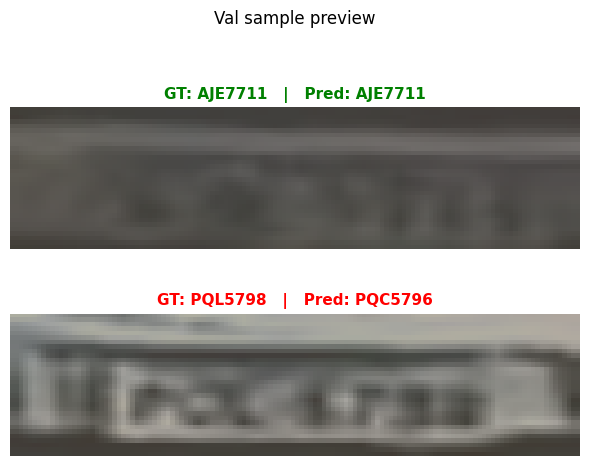

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  10 | Train Loss 0.1409  Acc 0.8178 | Val Loss 0.3288  Acc 0.6738 |


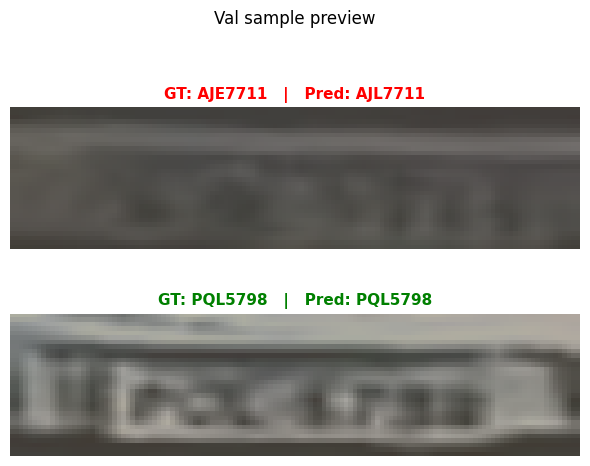

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  11 | Train Loss 0.1255  Acc 0.8360 | Val Loss 0.3325  Acc 0.6875 |


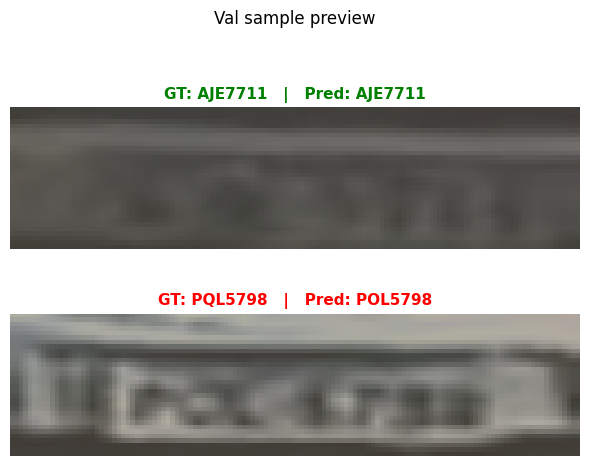

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  12 | Train Loss 0.1155  Acc 0.8457 | Val Loss 0.3233  Acc 0.7012 |


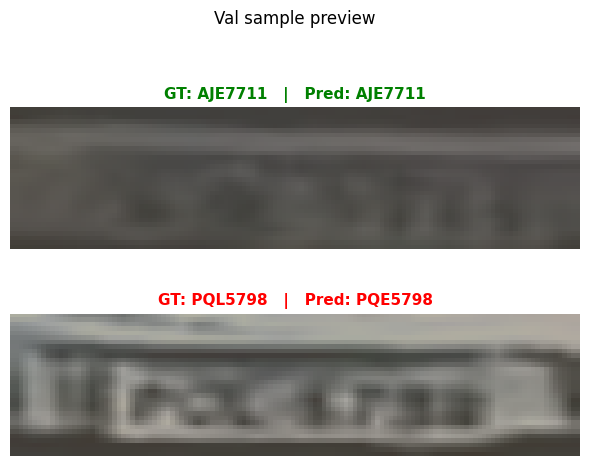

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  13 | Train Loss 0.1051  Acc 0.8534 | Val Loss 0.3280  Acc 0.6987 |


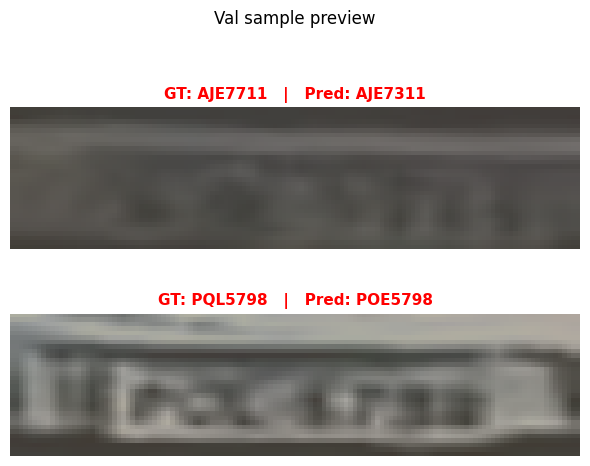

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  14 | Train Loss 0.0937  Acc 0.8669 | Val Loss 0.3114  Acc 0.6904 |


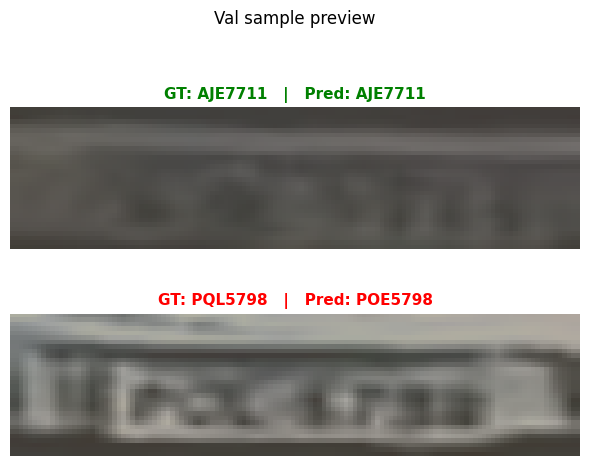

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  15 | Train Loss 0.0841  Acc 0.8769 | Val Loss 0.3324  Acc 0.6934 |


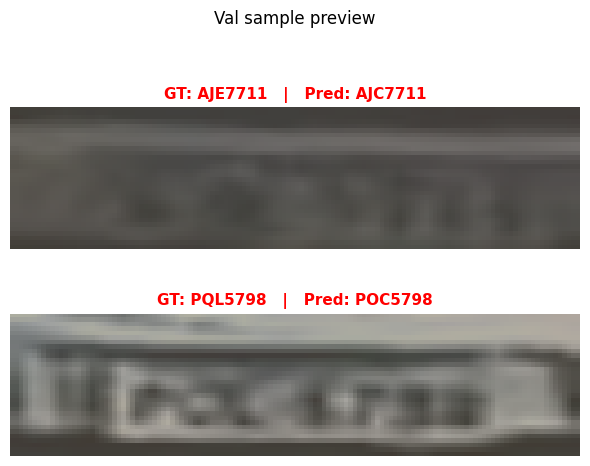

Train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  16 | Train Loss 0.0729  Acc 0.8904 | Val Loss 0.3127  Acc 0.7256 |


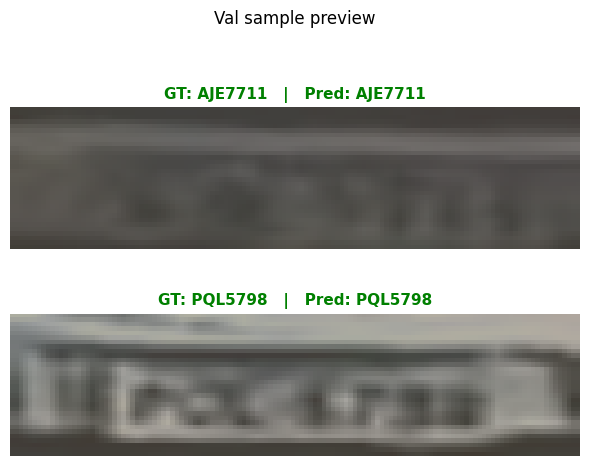

Train:   0%|          | 0/563 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  17 | Train Loss 0.0628  Acc 0.9047 | Val Loss 0.3181  Acc 0.7231 |


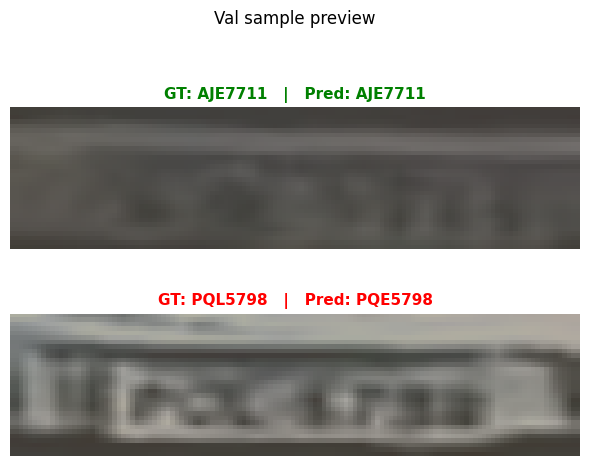

Train:   0%|          | 0/563 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  18 | Train Loss 0.0528  Acc 0.9134 | Val Loss 0.3362  Acc 0.7236 |


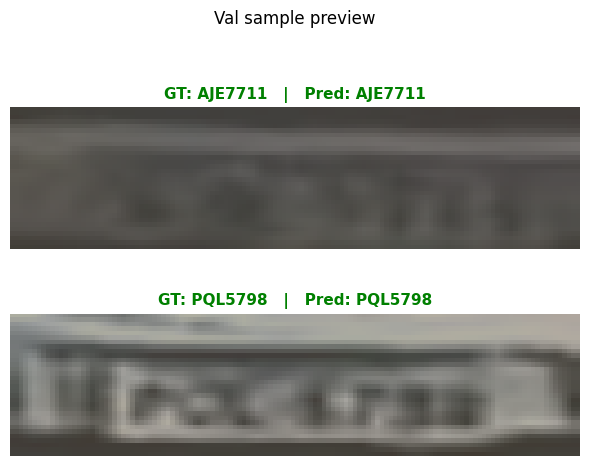

Train:   0%|          | 0/563 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  19 | Train Loss 0.0446  Acc 0.9237 | Val Loss 0.3352  Acc 0.7446 |


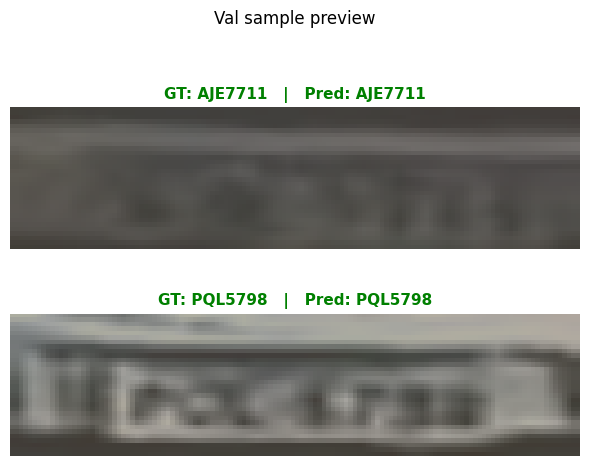

Early stop tại epoch 19 | best val loss: 0.3114
Training hoàn tất, đã load best model


In [31]:
model, metrics = train(
    model, optimizer, scheduler, criterion, train_loader, val_loader, epochs, early_stop_count,
    best_model_path, log_interval, warmup_epochs, device
)

In [35]:
def visualize_predictions(model, loader, device='cpu', n_samples=6, mode='test'):
    """
    mode='test'       : hiện track_id, GT label, prediction (màu xanh/đỏ)
    mode='blind_test' : hiện track_id, prediction only
    """
    model.eval()

    batch = next(iter(loader))
    if mode == 'test':
        images, targets, track_ids = batch   # collate_fn_test phải trả thêm targets
    else:
        images, track_ids = batch

    images = images.to(device)
    with torch.no_grad():
        logits = model(images)
        preds  = decode_pred(logits.cpu())

    images_cpu = images.detach().cpu()
    n_samples  = min(n_samples, images_cpu.size(0))
    n_frames   = images_cpu.size(1)

    fig, axes = plt.subplots(
        n_samples, n_frames,
        figsize=(n_frames * 3, n_samples * 2.5)
    )
    if n_samples == 1:
        axes = [axes]

    for row_idx in range(n_samples):
        pred_label = preds[row_idx]
        track_id   = track_ids[row_idx]

        if mode == 'test':
            gt = ''.join(vocab[i] for i in targets[row_idx].tolist())
            correct = pred_label == gt
            color   = '#4CAF50' if correct else '#F44336'  # xanh nếu đúng, đỏ nếu sai
            title   = f'{track_id}\nGT: {gt}  |  Pred: {pred_label}'
        else:
            color = '#2196F3'
            title = f'{track_id}\nPred: {pred_label}'

        for col_idx in range(n_frames):
            ax  = axes[row_idx][col_idx]
            img = unnormalize(images_cpu[row_idx, col_idx])
            ax.imshow(img)
            ax.axis('off')
            ax.set_xlabel(f'frame {col_idx + 1}', fontsize=7, labelpad=2)

            if col_idx == 0:
                ax.set_title(title, fontsize=9, fontweight='bold',
                             color=color, loc='left', pad=3)

    plt.suptitle(
        f'{"Test" if mode == "test" else "Blind Test"} — Inference Preview',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(f'inference_preview_{mode}.png', dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
visualize_predictions(model, test_loader, device=device, n_samples=16, mode='test')

In [32]:
def predict_blind_test(model, test_loader, device='cpu', save_path='./test_predictions.csv', checkpoint_path=None):
    if checkpoint_path is not None:
        if not os.path.isfile(checkpoint_path):
            raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint.get('model_state_dict', checkpoint)

        # Handle DataParallel/non-DataParallel key mismatch automatically.
        try:
            model.load_state_dict(state_dict)
        except RuntimeError:
            if any(k.startswith('module.') for k in state_dict.keys()):
                state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}
            else:
                state_dict = {f'module.{k}': v for k, v in state_dict.items()}
            model.load_state_dict(state_dict)

        print(f'Loaded model weights from: {checkpoint_path}')

    model.eval()
    results = []

    with torch.no_grad():
        for images, track_ids in tqdm(test_loader, desc='Predict', leave=False):
            images = images.to(device)
            logits = model(images)
            preds = decode_pred(logits.cpu())

            for track_id, pred in zip(track_ids, preds):
                results.append({
                    'track_id': track_id,
                    'plate_text': pred
                })

    # Sort by numeric suffix if available (track_10005 -> 10005).
    def _sort_key(row):
        track_id = row['track_id']
        try:
            return int(track_id.split('_')[-1])
        except ValueError:
            return track_id

    results.sort(key=_sort_key)

    with open(save_path, 'w', encoding='utf-8') as f:
        f.write('track_id,plate_text\n')
        for row in results:
            f.write(f"{row['track_id']},{row['plate_text']}\n")

    print(f'Saved {len(results)} predictions to: {save_path}')
    return results


predict_blind_test(model, blind_test_loader, device)